Initial Weights: [0. 0. 0.]

Epoch 1

Update 1
Weights = [-0.1  0.   0. ]

Update 2
Weights = [0.  0.  0.1]

Update 3
Weights = [-0.1 -0.1  0. ]

Epoch 2

Update 4
Weights = [ 0.  -0.1  0.1]

Update 5
Weights = [0.1 0.  0.1]

Update 6
Weights = [ 0.  -0.1  0. ]

Epoch 3

Update 7
Weights = [-0.1 -0.1  0. ]

Update 8
Weights = [ 0.  -0.1  0.1]

Update 9
Weights = [0.1 0.  0.1]

Update 10
Weights = [ 0.  -0.1  0. ]


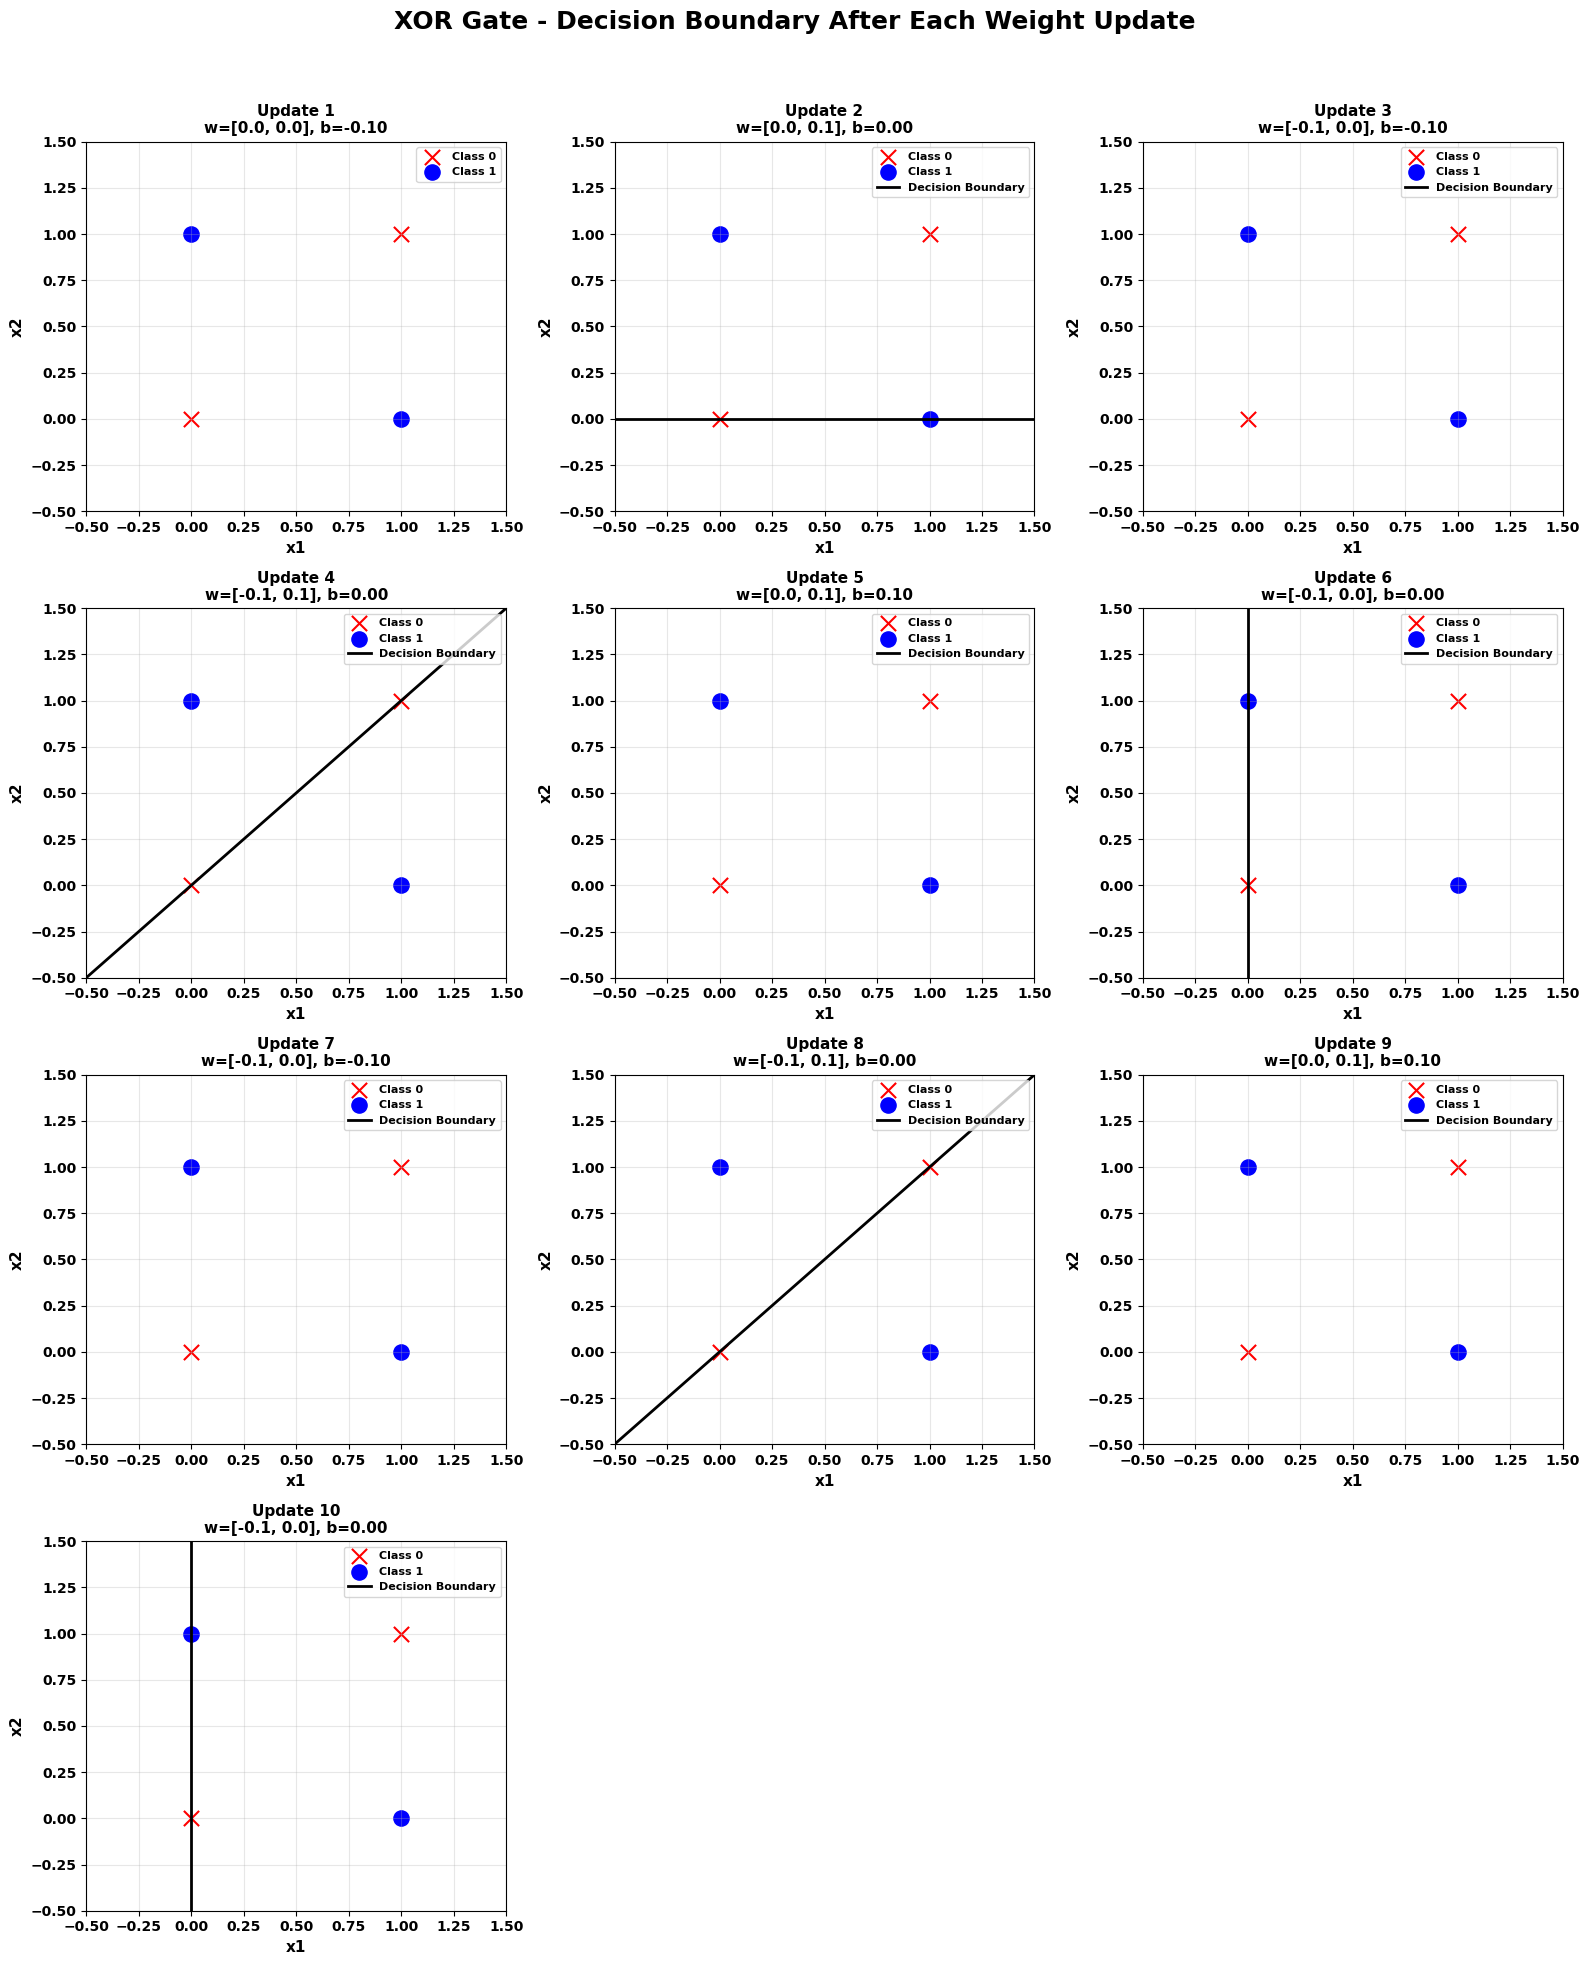

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# XOR Dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR targets
y = np.array([0, 1, 1, 0])

# Add bias input (x0 = 1)
X_bias = np.c_[np.ones(len(X)), X]


# Perceptron Parameters
learning_rate = 0.1
epochs = 3

weights = np.zeros(3)
weight_history = []

print("Initial Weights:", weights)

update_count = 0

for epoch in range(epochs):

    print(f"\nEpoch {epoch + 1}")
    error = False
    for xi, target in zip(X_bias, y):

        net = np.dot(weights, xi)
        prediction = 1 if net >= 0 else 0
        update = learning_rate * (target - prediction)

        if update != 0:
            weights += update * xi
            update_count += 1

            print(f"\nUpdate {update_count}")
            print("Weights =", weights)

            weight_history.append(weights.copy())
            error = True

    if not error:
        print("\nPerceptron Converged.")
        break

num_updates = len(weight_history)

cols = 3
rows = math.ceil(num_updates / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

for i, w in enumerate(weight_history):

    ax = axes[i]

    # Class 0
    class0 = X[y == 0]
    ax.scatter(
        class0[:, 0],
        class0[:, 1],
        color='red',
        marker='x',
        s=120,
        label='Class 0'
    )

    # Class 1
    class1 = X[y == 1]
    ax.scatter(
        class1[:, 0],
        class1[:, 1],
        color='blue',
        s=120,
        label='Class 1'
    )

    bias = w[0]
    w1 = w[1]
    w2 = w[2]

    # Decision Boundary
    if abs(w2) > 1e-8:

        x = np.linspace(-0.5, 1.5, 100)
        y_line = -(bias + w1 * x) / w2
        ax.plot(x, y_line, color='black', linewidth=2, label='Decision Boundary')

    elif abs(w1) > 1e-8:

        x = -bias / w1
        ax.axvline(x, color='black', linewidth=2, label='Decision Boundary')

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    ax.set_xlabel("x1", fontsize=11, fontweight='bold')
    ax.set_ylabel("x2", fontsize=11, fontweight='bold')

    ax.grid(True, alpha=0.3)

    for tick in ax.get_xticklabels():
        tick.set_fontweight('bold')

    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')

    ax.set_title(
        f"Update {i+1}\n"
        f"w=[{w1:.1f}, {w2:.1f}], b={bias:.2f}",
        fontsize=11,
        fontweight='bold'
    )

    legend = ax.legend(loc='upper right', fontsize=8)

    for text in legend.get_texts():
        text.set_fontweight('bold')


for j in range(num_updates, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "XOR Gate - Decision Boundary After Each Weight Update",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "xor_decision_boundaries.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()